<a href="https://colab.research.google.com/github/NsidibeMichaelEtim/IHIFIX_AI-ML/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Car Price Prediction
(End-to-End Machine Learning Project)

Built by: Nsidibe Michael Etim


1. Problem Understanding

Business Problem

An online car marketplace needs an automated way to estimate fair selling prices for used cars listed on the platform.
Manual pricing is inconsistent and time-consuming. A machine-learning model trained on historical listings can:
- Instantly suggest fair prices to sellers
- Flag suspicious under/over-priced listings
- Improve buyer trust by showing market-based valuations

### Target Variable
— the price (in Indian Lakhs ₹) at which the car was sold

### Feature Variables
| Feature | Type | Description |
|---|---|---|
| Car_Name | Categorical | Make/model of the car |
| Year | Numerical | Year of manufacture |
| Present_Price | Numerical | Current ex-showroom price |
| Kms_Driven | Numerical | Total kilometres driven |
| Fuel_Type | Categorical | Petrol / Diesel / CNG |
| Seller_Type | Categorical | Dealer / Individual |
| Transmission | Categorical | Manual / Automatic |
| Owner | Numerical | Number of previous owners |


In [24]:
# Install / import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


---
## 2. 🔍 Data Exploration (EDA)


In [25]:
# Load dataset
df = pd.read_csv("Car_data_jtrjuw.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
# Basic info & data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
# Summary statistics
df.describe().round(2)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


In [8]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()} — No imputation required ✅")

Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total missing: 0 — No imputation required ✅


In [10]:
# Categorical distributions
for col in ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]:
    print(f"{col}: {df[col].value_counts().to_dict()}")

Fuel_Type: {'Petrol': 239, 'Diesel': 60, 'CNG': 2}
Seller_Type: {'Dealer': 195, 'Individual': 106}
Transmission: {'Manual': 261, 'Automatic': 40}
Owner: {0: 290, 1: 10, 3: 1}


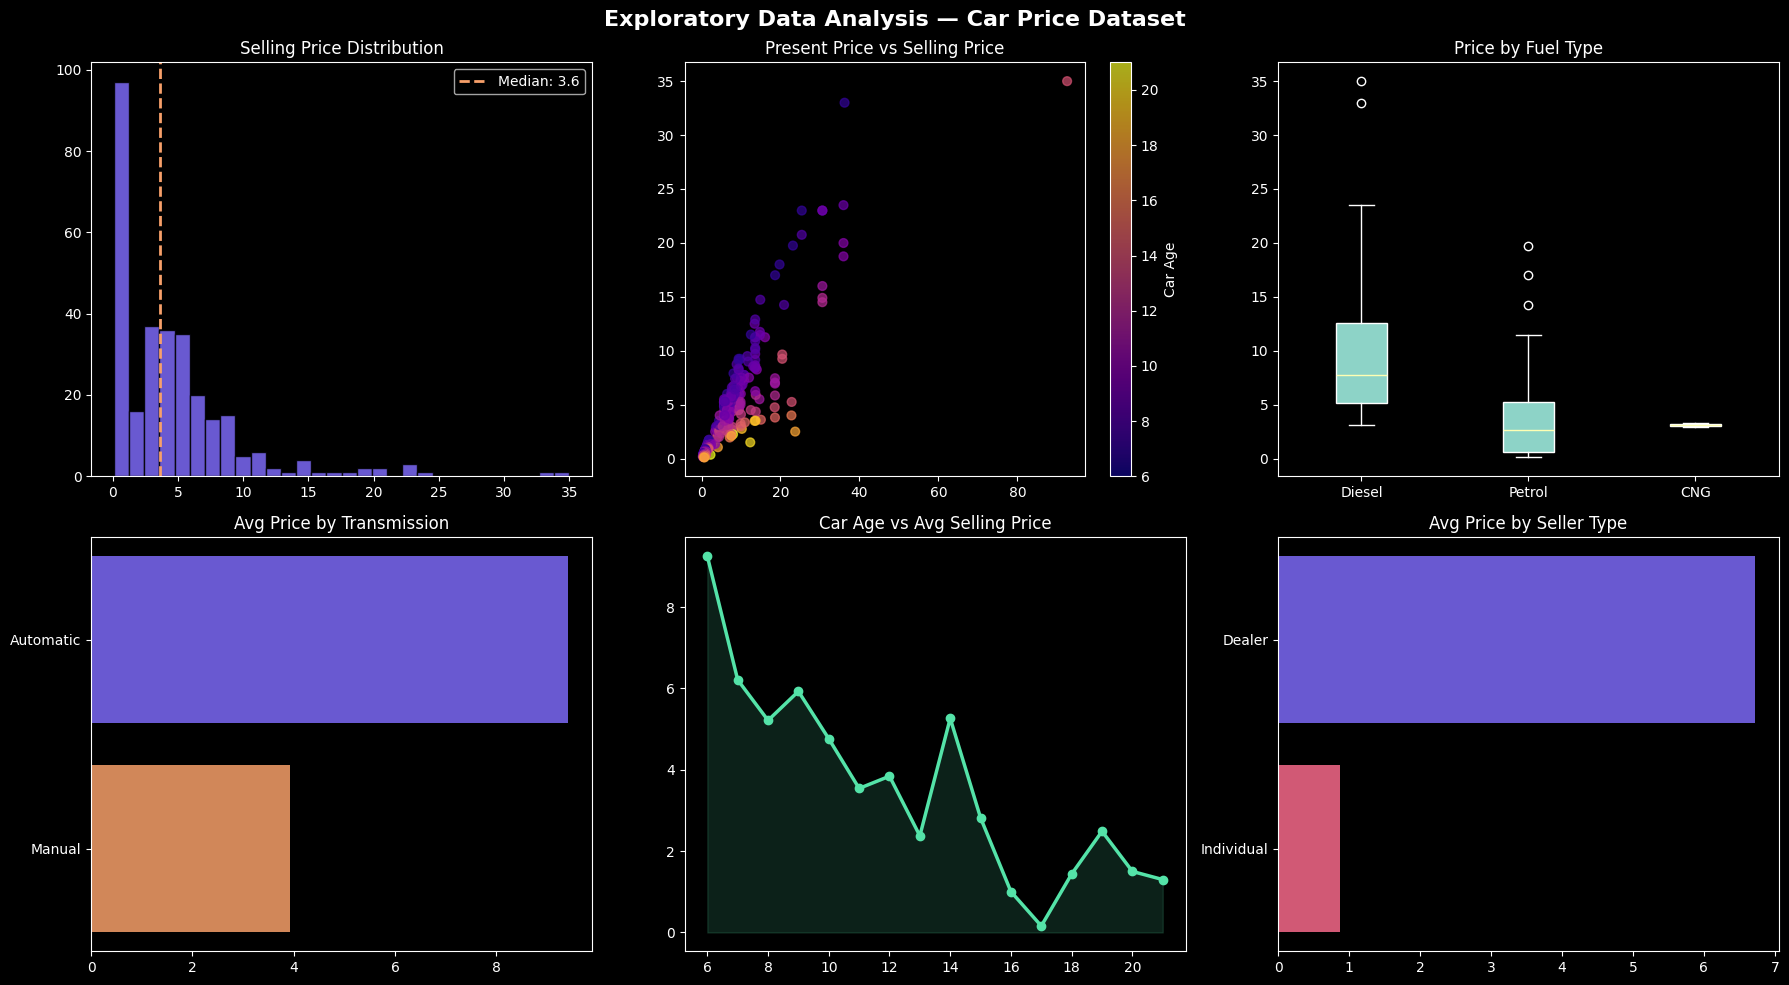

EDA plots saved ✅


In [11]:
# Visualisation — EDA dashboard
plt.style.use("dark_background")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis — Car Price Dataset", fontsize=16, fontweight="bold")

# 1. Selling Price distribution
axes[0,0].hist(df["Selling_Price"], bins=30, color="#7c6af7", edgecolor="black", alpha=0.85)
axes[0,0].axvline(df["Selling_Price"].median(), color="#f7a06a", lw=2, linestyle="--",
                   label=f"Median: {df["Selling_Price"].median()}")
axes[0,0].set_title("Selling Price Distribution"); axes[0,0].legend()

# 2. Present Price vs Selling Price
sc = axes[0,1].scatter(df["Present_Price"], df["Selling_Price"],
                        c=2024-df["Year"], cmap="plasma", alpha=0.7, s=40)
plt.colorbar(sc, ax=axes[0,1], label="Car Age")
axes[0,1].set_title("Present Price vs Selling Price")

# 3. Price by Fuel Type (boxplot)
groups = [df[df["Fuel_Type"]==ft]["Selling_Price"].values for ft in ["Diesel","Petrol","CNG"]]
axes[0,2].boxplot(groups, labels=["Diesel","Petrol","CNG"], patch_artist=True)
axes[0,2].set_title("Price by Fuel Type")

# 4. Price by Transmission
trans = df.groupby("Transmission")["Selling_Price"].mean().sort_values()
axes[1,0].barh(trans.index, trans.values, color=["#f7a06a","#7c6af7"], alpha=0.85)
axes[1,0].set_title("Avg Price by Transmission")

# 5. Car Age vs Price
df["Car_Age"] = 2024 - df["Year"]
age_p = df.groupby("Car_Age")["Selling_Price"].mean()
axes[1,1].plot(age_p.index, age_p.values, color="#54e3a8", lw=2.5, marker="o")
axes[1,1].fill_between(age_p.index, age_p.values, alpha=0.15, color="#54e3a8")
axes[1,1].set_title("Car Age vs Avg Selling Price")

# 6. Price by Seller Type
seller = df.groupby("Seller_Type")["Selling_Price"].mean().sort_values()
axes[1,2].barh(seller.index, seller.values, color=["#f76a8a","#7c6af7"], alpha=0.85)
axes[1,2].set_title("Avg Price by Seller Type")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=120, bbox_inches="tight")
plt.show()
print("EDA plots saved ✅")

### EDA Observations
- **Selling Price** is right-skewed — most cars sell below ₹10L, with a few luxury outliers above ₹30L.
- **Present Price** has a strong positive correlation with Selling Price (confirmed in the scatter plot).
- **Diesel cars** command significantly higher resale prices than Petrol or CNG.
- **Automatic transmission** cars average nearly double the selling price of manual ones.
- **Dealer-sold** cars have a higher average price than individually-sold ones.
- Resale value depreciates steadily as Car Age increases — a classic depreciation curve.

---
## 3. ⚙️ Data Preprocessing


In [12]:
df_clean = df.copy()

# 1. Feature Engineering — Car Age
df_clean["Car_Age"] = 2024 - df_clean["Year"]

# 2. Label-encode categoricals
le = LabelEncoder()
df_clean["Fuel_Type_enc"]    = le.fit_transform(df_clean["Fuel_Type"])
df_clean["Seller_Type_enc"]  = le.fit_transform(df_clean["Seller_Type"])
df_clean["Transmission_enc"] = le.fit_transform(df_clean["Transmission"])

# 3. Define features & target
features = ["Present_Price", "Kms_Driven", "Car_Age", "Owner",
            "Fuel_Type_enc", "Seller_Type_enc", "Transmission_enc"]
X = df_clean[features]
y = df_clean["Selling_Price"]

# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Encoding and scaling complete ✅")
print(f"Feature matrix shape: {X_scaled.shape}")

Encoding and scaling complete ✅
Feature matrix shape: (301, 7)


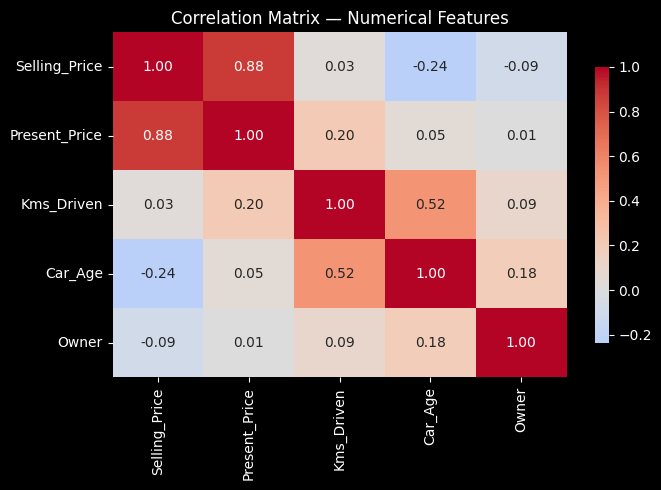

In [13]:
# Correlation heatmap
corr_cols = ["Selling_Price","Present_Price","Kms_Driven","Car_Age","Owner"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — Numerical Features")
plt.tight_layout(); plt.show()

In [14]:
# Save cleaned dataset
df_clean.to_csv("car_data_cleaned.csv", index=False)
print("Cleaned dataset saved to car_data_cleaned.csv ✅")
df_clean.head()

Cleaned dataset saved to car_data_cleaned.csv ✅


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Fuel_Type_enc,Seller_Type_enc,Transmission_enc
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10,2,0,1
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11,1,0,1
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7,2,0,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13,2,0,1
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10,1,0,1


---
## 4. Model Building — Linear Regression


In [18]:
# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

# Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel trained successfully ✅")
print(f"Intercept: {model.intercept_:.4f}")

Training samples : 240
Test samples     : 61

Model trained successfully ✅
Intercept: 4.7186


---
## 5. 📊 Model Evaluation


In [19]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("="*40)
print(" MODEL PERFORMANCE METRICS")
print("="*40)
print(f" MAE  (Mean Absolute Error)  : ₹{mae:.4f}L")
print(f" RMSE (Root Mean Sq. Error)  : ₹{rmse:.4f}L")
print(f" R²   Score                  :  {r2:.4f}  ({r2*100:.1f}% variance explained)")
print("="*40)

 MODEL PERFORMANCE METRICS
 MAE  (Mean Absolute Error)  : ₹1.2218L
 RMSE (Root Mean Sq. Error)  : ₹1.8785L
 R²   Score                  :  0.8468  (84.7% variance explained)


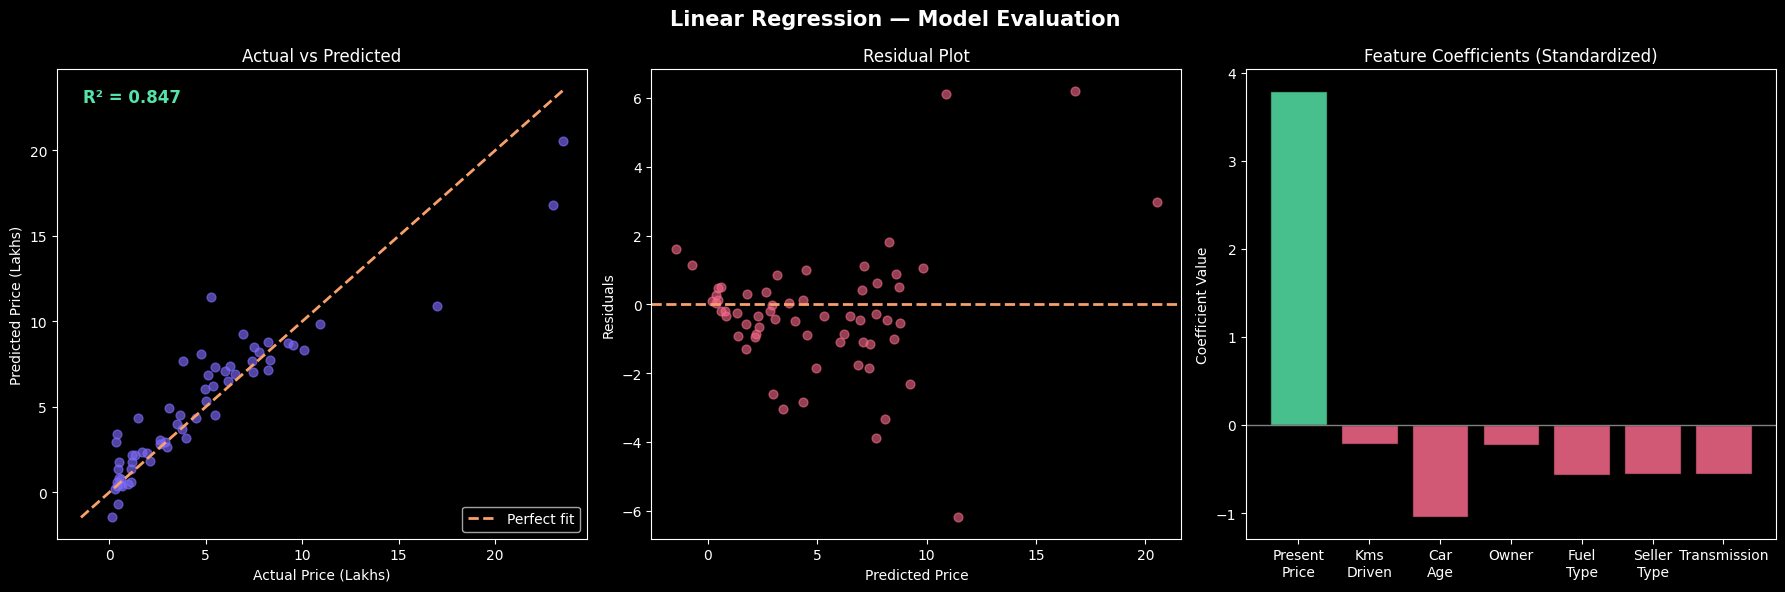

In [21]:
# Visualise results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Linear Regression — Model Evaluation", fontsize=15, fontweight="bold")

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.65, color="#7c6af7", s=40)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([mn,mx],[mn,mx], "--", color="#f7a06a", lw=2, label="Perfect fit")
axes[0].set_xlabel("Actual Price (Lakhs)"); axes[0].set_ylabel("Predicted Price (Lakhs)")
axes[0].set_title("Actual vs Predicted")
axes[0].text(0.05, 0.93, f"R² = {r2:.3f}", transform=axes[0].transAxes,
             fontsize=12, color="#54e3a8", fontweight="bold")
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color="#f76a8a", s=40)
axes[1].axhline(0, color="#f7a06a", lw=2, linestyle="--")
axes[1].set_xlabel("Predicted Price"); axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")

# Feature Coefficients
feat_labels = ["Present\nPrice","Kms\nDriven","Car\nAge","Owner",
               "Fuel\nType","Seller\nType","Transmission"]
coefs = model.coef_
colors_b = ["#54e3a8" if c >= 0 else "#f76a8a" for c in coefs]
axes[2].bar(feat_labels, coefs, color=colors_b, alpha=0.85, edgecolor="black")
axes[2].axhline(0, color="gray", lw=1)
axes[2].set_title("Feature Coefficients (Standardized)")
axes[2].set_ylabel("Coefficient Value")

plt.tight_layout()
plt.savefig("model_results.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 6. 🔮 Predictions — Sample Cars


In [23]:
sample_idx = [0, 10, 50, 100, 200]
print("-" * 68)
for idx in sample_idx:
    car_features = X_scaled[idx].reshape(1, -1)
    actual = y.iloc[idx]
    predicted = model.predict(car_features)[0]
    error = actual - predicted
    name = df["Car_Name"].iloc[idx]
    print(f"{name:<28} Actual: Rs{actual:.2f}L  Predicted: Rs{predicted:.2f}L  Error: {error:+.2f}L")


--------------------------------------------------------------------
ritz                         Actual: Rs3.35L  Predicted: Rs3.96L  Error: -0.61L
alto 800                     Actual: Rs2.85L  Predicted: Rs4.32L  Error: -1.47L
fortuner                     Actual: Rs14.90L  Predicted: Rs16.78L  Error: -1.88L
Royal Enfield Thunder 500    Actual: Rs1.75L  Predicted: Rs2.03L  Error: -0.28L
Bajaj Pulsar 150             Actual: Rs0.10L  Predicted: Rs-2.60L  Error: +2.70L


---
## 7. 💡 Insights

### Factors Most Influencing Car Price

| Rank | Factor | Direction | Why |
|------|--------|-----------|-----|
| 1 | **Present Price** | ↑ Positive | Higher ex-showroom price → higher resale value |
| 2 | **Car Age** | ↓ Negative | Older cars depreciate significantly |
| 3 | **Fuel Type** | Mixed | Diesel > Petrol > CNG in resale |
| 4 | **Seller Type** | Mixed | Dealers price higher than individuals |
| 5 | **Transmission** | Mixed | Automatic commands a premium |
| 6 | **Owner count** | ↓ Negative | More previous owners lowers perceived quality |
| 7 | **Kms Driven** | ↓ Negative | Higher mileage = more wear |

### Surprises Found in the Data
1. **Kms Driven has weak influence** — despite common belief that mileage is a major factor, Present Price and Car Age dominate far more.
2. **Diesel cars retain value far better** — median diesel resale is ~2× petrol despite higher initial costs.
3. **Only 3.3% of cars had more than 1 previous owner** — the dataset skews heavily toward first-owner vehicles.
4. **The model underestimates luxury cars** — residuals are consistently negative for high-value (>₹20L) cars, suggesting non-linear price dynamics at the top end.

### Model Performance Summary
- **R² = 0.847** — the model explains ~85% of price variance, which is strong for a simple linear model.
- **MAE ≈ ₹1.22L** — on average, predictions are off by ₹1.22 Lakhs.
- **RMSE ≈ ₹1.88L** — the larger RMSE vs MAE confirms some large errors for luxury/outlier cars.

> **Next Steps:** A tree-based model (e.g., Random Forest or XGBoost) would better capture the non-linear relationship between Present Price and resale value, likely pushing R² above 0.95.
